# Level 2 + 特徵工程

基於 `level2.ipynb`（Single Model，目前最佳 $8,688,900）加入衍生特徵，目標提升 AUC。

| 新特徵 | 公式 | 邏輯 |
|--------|------|------|
| `AvgGift` | TotalGift / Frequency | 平均單次捐款，比 Total 更穩定 |
| `GiftTrend` | AmtLastYear − AvgGift | 去年 vs 平均趨勢，正值 = 上升 |
| `DonationRate` | Frequency / Seniority | 每年捐款比例，越高越規律 |
| `GiftRange` | MaxGift − MinGift | 捐款波動幅度 |
| `RecentActivity` | GaveLastYear × AmtLastYear | 近期活躍度（交叉項） |
| `log_TotalGift` | log1p(TotalGift) | 壓縮右偏 |
| `log_Salary` | log1p(Salary) | 壓縮右偏 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

In [2]:
# ============================================================
# 1. 載入 & 特徵工程
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def add_features(df):
    """加入衍生特徵，原始欄位保留不動"""
    d = df.copy()
    freq  = d['Frequency'].clip(lower=1)
    senio = d['Seniority'].clip(lower=1)

    d['AvgGift']        = d['TotalGift'] / freq
    d['GiftTrend']      = d['AmtLastYear'] - d['AvgGift']
    d['DonationRate']   = d['Frequency']  / senio
    d['GiftRange']      = d['MaxGift']    - d['MinGift']
    d['RecentActivity'] = d['GaveLastYear'] * d['AmtLastYear']
    d['log_TotalGift']  = np.log1p(d['TotalGift'])
    d['log_Salary']     = np.log1p(d['Salary'])
    return d

train_raw = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train_raw = train_raw.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)
train = add_features(train_raw)

print(f'R2_TRAIN shape: {train.shape}')
print(f'新增特徵: AvgGift, GiftTrend, DonationRate, GiftRange, RecentActivity, log_TotalGift, log_Salary')
print(f'\n新特徵統計:')
new_feats = ['AvgGift', 'GiftTrend', 'DonationRate', 'GiftRange', 'RecentActivity']
print(train[new_feats].describe().round(2))

R2_TRAIN shape: (100000, 29)
新增特徵: AvgGift, GiftTrend, DonationRate, GiftRange, RecentActivity, log_TotalGift, log_Salary

新特徵統計:
         AvgGift  GiftTrend  DonationRate  GiftRange  RecentActivity
count  100000.00  100000.00     100000.00  100000.00       100000.00
mean       60.52     -48.54          0.48      42.58           11.98
std       173.95     200.19          0.29     240.57          103.56
min        10.00  -10000.00          0.10       0.00            0.00
25%        20.00     -48.33          0.25       0.00            0.00
50%        26.67     -25.00          0.40       0.00            0.00
75%        50.00     -17.50          0.62      15.00            0.00
max     10000.00    9865.00          1.00    9990.00        10000.00


In [3]:
# ============================================================
# 2. 前處理 & 切分
# ============================================================

DROP_COLS = ['ID', 'LastName', 'FirstName', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

X_all    = preprocess(train)
y_cls    = train['GaveThisYear'].astype(int)
y_amt    = train['AmtThisYear']
feature_cols = X_all.columns.tolist()

X_train, X_val, y_cls_train, y_cls_val, y_amt_train, y_amt_val = train_test_split(
    X_all, y_cls, y_amt, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'總特徵數: {len(feature_cols)}（原本 20，新增 7）')
print(f'新特徵: {[c for c in feature_cols if c in ["AvgGift","GiftTrend","DonationRate","GiftRange","RecentActivity","log_TotalGift","log_Salary"]]}')

總特徵數: 27（原本 20，新增 7）
新特徵: ['AvgGift', 'GiftTrend', 'DonationRate', 'GiftRange', 'RecentActivity', 'log_TotalGift', 'log_Salary']


In [4]:
# ============================================================
# 3. 分類模型 & AUC 比較（含 vs 不含新特徵）
# ============================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf.fit(X_train_sc, y_cls_train)
auc_fe = roc_auc_score(y_cls_val, clf.predict_proba(X_val_sc)[:, 1])

print(f'分類模型 AUC（含新特徵）: {auc_fe:.4f}')
print(f'比較 level2.ipynb 基準:    0.7051')
print(f'提升: {auc_fe - 0.7051:+.4f}')

# Feature importance（Top 15）
fi = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
new_feat_names = ['AvgGift','GiftTrend','DonationRate','GiftRange','RecentActivity','log_TotalGift','log_Salary']

print(f'\nTop 15 Feature Importance:')
for feat, imp in fi.head(15).items():
    tag = ' ★新' if feat in new_feat_names else ''
    print(f'  {feat:<25} {imp:.4f}{tag}')

分類模型 AUC（含新特徵）: 0.7051
比較 level2.ipynb 基準:    0.7051
提升: -0.0000

Top 15 Feature Importance:
  Contact                   0.2085
  NbActivities              0.1724
  Referrals                 0.1013
  SeniorList                0.0985
  Frequency                 0.0769
  Age                       0.0684
  Woman                     0.0418
  Recency                   0.0326
  DonationRate              0.0246 ★新
  log_Salary                0.0190 ★新
  AmtLastYear               0.0187
  GiftTrend                 0.0185 ★新
  GaveLastYear              0.0181
  RecentActivity            0.0160 ★新
  Salary                    0.0156


In [5]:
# ============================================================
# 4. 回歸模型
# ============================================================

donor_mask_train = y_amt_train > 0
donor_mask_val   = y_amt_val   > 0
X_donors_train   = X_train[donor_mask_train]
y_donors_train   = y_amt_train[donor_mask_train]
X_donors_val     = X_val[donor_mask_val]
y_donors_val     = y_amt_val[donor_mask_val]

scaler_reg = StandardScaler()
reg = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg.fit(scaler_reg.fit_transform(X_donors_train), np.log1p(y_donors_train))

y_pred_log = reg.predict(scaler_reg.transform(X_donors_val))
r2_log  = r2_score(np.log1p(y_donors_val), y_pred_log)
r2_orig = r2_score(y_donors_val, np.expm1(y_pred_log).clip(min=0))

print(f'回歸模型:')
print(f'  R² (log space):  {r2_log:.4f}  （基準: 0.0155）')
print(f'  R² (orig space): {r2_orig:.4f}')

回歸模型:
  R² (log space):  0.0133  （基準: 0.0155）
  R² (orig space): -0.0200


Uplift 驗證（含特徵工程）:
  Uplift > 成本: 聯繫 11,551 人, Surplus = $122,325
  真實最佳:      聯繫 19,998 人, Surplus = $173,385
  全部聯繫:      Surplus = $173,375
  策略效率: 70.6%  （基準 level2: 70.3%）


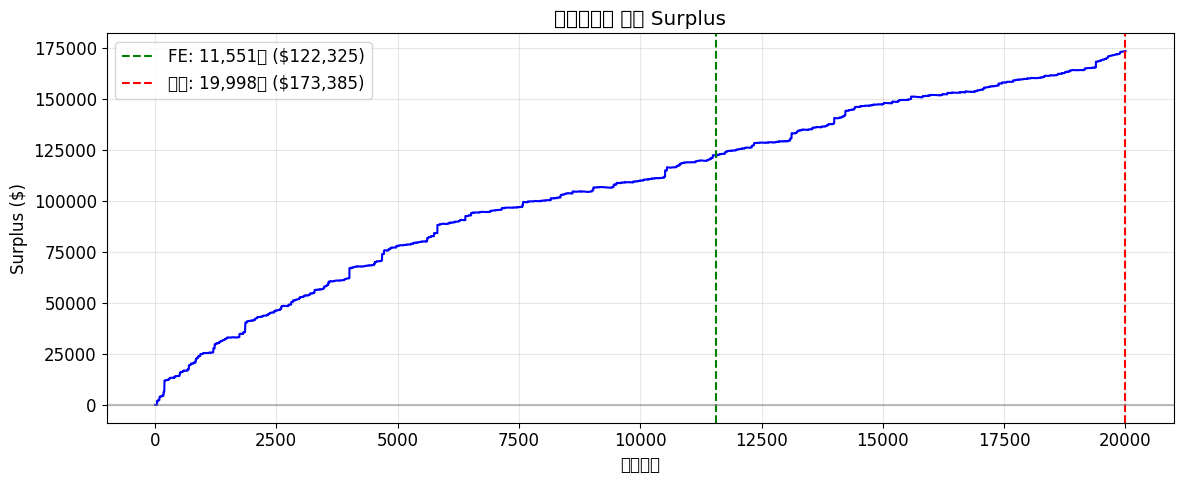

In [6]:
# ============================================================
# 5. Uplift 驗證
# ============================================================

COST_SCHEDULE = [(60_000, 5), (np.inf, 25)]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier; prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit: return cost
    return schedule[-1][1]

def score_with_contact(X_df, contact_val, clf, scaler_cls, reg, scaler_reg):
    Xc = X_df.copy(); Xc['Contact'] = contact_val
    P = clf.predict_proba(scaler_cls.transform(Xc))[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(Xc))).clip(min=0)
    return P, E, P * E

P1_val, E1_val, EV1_val = score_with_contact(X_val, 1, clf, scaler, reg, scaler_reg)
P0_val, E0_val, EV0_val = score_with_contact(X_val, 0, clf, scaler, reg, scaler_reg)
uplift_val = EV1_val - EV0_val

val_df = pd.DataFrame({
    'EV_contact': EV1_val, 'EV_nocontact': EV0_val,
    'uplift': uplift_val, 'actual_amt': y_amt_val.values,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

val_df['rank']          = range(1, len(val_df)+1)
val_df['marginal_cost'] = val_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
val_df['cum_donation']  = val_df['actual_amt'].cumsum()
val_df['cum_cost']      = val_df['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
val_df['cum_surplus']   = val_df['cum_donation'] - val_df['cum_cost']

our_n        = (val_df['uplift'] > val_df['marginal_cost']).sum()
our_surplus  = val_df.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n       = val_df['cum_surplus'].idxmax() + 1
best_surplus = val_df['cum_surplus'].max()

print(f'Uplift 驗證（含特徵工程）:')
print(f'  Uplift > 成本: 聯繫 {our_n:,} 人, Surplus = ${our_surplus:,.0f}')
print(f'  真實最佳:      聯繫 {best_n:,} 人, Surplus = ${best_surplus:,.0f}')
print(f'  全部聯繫:      Surplus = ${val_df["cum_surplus"].iloc[-1]:,.0f}')
print(f'  策略效率: {our_surplus/best_surplus:.1%}  （基準 level2: 70.3%）')

# 累積 Surplus 圖
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(val_df['rank'], val_df['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'FE: {our_n:,}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'最佳: {best_n:,}人 (${best_surplus:,.0f})')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數'); ax.set_ylabel('Surplus ($)')
ax.set_title('特徵工程版 累積 Surplus'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# ============================================================
# 6. 全量重訓練 → 對 SCOREDATA 評分
# ============================================================

scaler_full = StandardScaler()
X_all_sc = scaler_full.fit_transform(X_all)
clf_full = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
clf_full.fit(X_all_sc, y_cls)
print('分類模型（全資料）完成')

donor_mask_all  = y_amt > 0
scaler_reg_full = StandardScaler()
reg_full = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
reg_full.fit(scaler_reg_full.fit_transform(X_all[donor_mask_all]), np.log1p(y_amt[donor_mask_all]))
print(f'回歸模型（全資料）完成, 捐款者: {donor_mask_all.sum():,}')

# 載入並加入特徵
score_c  = add_features(load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv'))
score_nc = add_features(load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv'))
assert (score_c['ID'].values == score_nc['ID'].values).all()
score_ids = score_c['ID'].copy()

def score_scoredata(df, clf, scaler_cls, reg, scaler_reg, feature_cols):
    X = preprocess(df, feature_cols=feature_cols)
    P = clf.predict_proba(scaler_cls.transform(X))[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(X))).clip(min=0)
    return P, E, P * E

P1s, E1s, EV1s = score_scoredata(score_c,  clf_full, scaler_full, reg_full, scaler_reg_full, feature_cols)
P0s, E0s, EV0s = score_scoredata(score_nc, clf_full, scaler_full, reg_full, scaler_reg_full, feature_cols)
uplift_s = EV1s - EV0s

print(f'\nUplift 統計: mean=${uplift_s.mean():.2f}, 正值={( uplift_s>0).sum():,}, 負值={( uplift_s<0).sum():,}')

分類模型（全資料）完成
回歸模型（全資料）完成, 捐款者: 20,315

Uplift 統計: mean=$6.60, 正值=92,559, 負值=7,441


In [8]:
# ============================================================
# 7. 四象限分類 & 匯出
# ============================================================

SURE_THING_THRESHOLD = 5

score_df = pd.DataFrame({
    'ID': score_ids.values, 'EV_contact': EV1s, 'EV_nocontact': EV0s, 'uplift': uplift_s,
}).sort_values('uplift', ascending=False).reset_index(drop=True)

score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify(row):
    if row['uplift'] > row['marginal_cost']:                                  return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= 0:  return 'Sure Thing'
    elif row['uplift'] < 0:                                                   return 'Sleeping Dog'
    else:                                                                      return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify, axis=1)
contact = score_df[score_df['quadrant'] == 'Persuadable']
n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print('四象限分布:')
print(score_df['quadrant'].value_counts())
print(f'\n聯繫: {n_contact:,} 人, 預估成本 ${total_cost:,.0f}')
print(f'\n比較:')
print(f'  level2.ipynb (基準):     53,277 人, AUC=0.7051')
print(f'  level2_fe.ipynb (本檔):  {n_contact:,} 人, AUC={auc_fe:.4f}')

import os
os.makedirs('output', exist_ok=True)
output_path = 'output/level2_fe_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 → {output_path}')

四象限分布:
quadrant
Persuadable     53594
Lost Cause      20927
Sure Thing      18038
Sleeping Dog     7441
Name: count, dtype: int64

聯繫: 53,594 人, 預估成本 $267,970

比較:
  level2.ipynb (基準):     53,277 人, AUC=0.7051
  level2_fe.ipynb (本檔):  53,594 人, AUC=0.7051

已匯出 → output/level2_fe_contact_list.csv
